# XBTorch::Example 06:Loss Landscapes

## Introduction

In this example, we will visualize neural network loss landscapes [1]. The particular examples we will focus on will be a software baseline network against a network trained with hardware-aware considerations. For the purposes of this notebook, we will assume that the training is already complete. 

See Example 05 for more information on how to prepare network training data in a format that is usable with the loss landscape visualization utilities from XBTorch demonstrated here.

## Getting Started

Let's import necessary dependencies.

In [1]:
# General Imports
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# XBTorch Imports
import xbtorch
import xbtorch.loss as xbloss
from xbtorch.patches import xbtorch_model
from xbtorch.devices import TabularCompactFeFETKriging

from nets.mlp import SimpleMLP

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'


Let's load model checkpoints from our previous example (Example 05).

In [3]:
# Load network performances for SW as well as the HWA trained network
with open("checkpoints/hwa_train_mlp_sw_example.pkl", "rb") as f:
    full_weights_sw = pickle.load(f)

with open("checkpoints/hwa_train_mlp_hwa_example.pkl", "rb") as f:
    full_weights_hwa = pickle.load(f)

## Constructing $M$

Following the methodology described in [1], the first step is to construct the matrix of parameter evolutions $M = [\vec{\theta}_0 - \vec{\theta}_n, ..., \vec{\theta}_{n-1} - \vec{\theta}_n]$. We do this for both the baseline and the HWA networks.

In [4]:
def construct_M(full_weights, layer_name, epochs):
    #  Construct the matrix of parameter evolutions i.e. M = [θ0−θn; · · · ; θn−1−θn] for the layer `layer_name`, see [1] for more details.
    M = []
    for epoch in range(epochs - 1):
        diff = full_weights[layer_name][epoch] - full_weights[layer_name][-1]
        M.append(diff.flatten())
    
    return np.array(M)

In [5]:
layer_name_sw = list(full_weights_sw.keys())[0] # let's perturb the first layer of our network
M_sw = construct_M(full_weights_sw, layer_name_sw, epochs=10)

layer_name_hwa = list(full_weights_hwa.keys())[0] # let's perturb the first layer of our network
M_hwa = construct_M(full_weights_hwa, layer_name_hwa, epochs=10)

## Projections to 2-dimensions

The next step is to project (or reduce) $M$ to a 2-dimensional space for easier visualization. XBTorch provides two mechanisms to implement these reductions. We can either utilize principal component analysis, or perform the projections completely randomly.

In [6]:
seed = 0

# SW network
path_sw_pca, reduced_dirs_sw_pca, extra_params_sw_pca = xbloss.reduction_pca(M_sw, seed=seed)
path_sw_random, reduced_dirs_sw_random, extra_params_sw_random = xbloss.reduction_random(M_sw, seed=seed)

# HWA network
path_hwa_pca, reduced_dirs_hwa_pca, extra_params_hwa_pca = xbloss.reduction_pca(M_hwa, seed=seed)
path_hwa_random, reduced_dirs_hwa_random, extra_params_hwa_random = xbloss.reduction_random(M_hwa, seed=seed)

## Initialize XBTorch

Before we compute loss landscapes, we need to initalize XBTorch, as we should ensure that all parameters match the model against which the parameter evolutions were recorded. The cells below are simply copied over from Example 05.

In [7]:
# XBTorch parameters
xb_patch_network = True
xb_device_model = "tab_fefet_compact_vgs_0.9_sd_1" # device model name goes here
weight_range = (-1, +1) # number formats used in forward and backward quantization conversions 
# loss_reduction_method = "pca" # loss landscape reduction method

# WAGE quantization parameters (https://arxiv.org/pdf/1802.04680)
wage_quantize = xb_patch_network
wage_params = { "wl_weight": 2, # 2 = ternary weights
                "wl_grad": 8,
                "wl_activation": 8,
                "wl_error": 8,
                "rounding_weight" : "nearest",
                "rounding_activation" : "nearest",
                "rounding_grad" : "nearest",
                "rounding_error" : "nearest",
               }

In [8]:
# Check if CUDA is available and select the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Init xbtorch
xb_device = TabularCompactFeFETKriging(xb_device_model)
xbtorch.initialize(device_type=xb_device,
                   pytorch_device=device,
                   weight_range=weight_range,
                   wage_quantize=wage_quantize,
                   wage_params=wage_params
                   )

Using device: cpu


## Prepare the dataset

We also need to prepare the dataset for our neural network, as we need to run data through our network for computing the loss landscape. Needless to say, this also has to match the dataset the network was actually trained on.

In [9]:
# Define transforms to apply to the data
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize the image data
])

# Load the MNIST training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Create data loaders for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True, generator=torch.Generator(device=device), num_workers=4)

## Prepare the model

In [10]:
# Define the model
input_size = 28 * 28
hidden_size = 150
output_size = 10

# Model
model_sw = SimpleMLP(input_size, hidden_size, output_size).to(device)

# Loss
criterion = nn.CrossEntropyLoss()

## Compute the loss landscape

A loss landscape is a way to visualize how a given neural network behaves when weights are perturbed. 

It is given by: $f(\alpha, \beta) = L(\vec{\theta}_i + \alpha \frac{\vec{\delta}}{\|\vec{\delta} \|} + \beta \frac{\vec{\eta}}{\|\vec{\eta} \|})$. 

where,

- $\vec{\theta}_i$ represents the i-th neural network layer after training (flattened).
- $\vec{\delta}$ and $\vec{\eta}$ represent the 2 reduced direction vectors (principal components or random vectors).
- $\alpha$, $\beta$ are scalars that we will shortly see. These dictate the degree of the overall perturbation applied to the network.

In the context of memristive neural networks, such a landscape could be interpreted as a way to gauge the robustness of the underlying training methodology. Assuming similar minimums, if a training methodology produces solutions that have flatter loss landscapes compared to another that produces sharper loss landscapes, then the former scheme is said to be more robust. This is because device-level and system-level non-idealities manifest as noise, akin to weight perturbations. 

XBTorch provides a helper utility inside `xbtorch.loss.compute_grid_loss()` for this purpose, where the process is fully abstracted. Let's define necessary parameters for this method.

In [11]:
x_range = (-5, +5) # range of the \alpha perturbation
y_range = (-5, +5) # range of the \beta perturbation

resolution = 0.25 # 0.25 # inversely related to step size, larger values -> smaller step sizes -> finer grids

epoch = 20 # which epoch to use as base weights before perturbation (the i in \theta_i)

We can now compute the actual landscapes.

In [12]:
# SW network
xv_sw_pca, yv_sw_pca, loss_grid_sw_pca = xbloss.compute_grid_loss(model_sw, full_weights_sw, layer_name_sw, x_range, y_range, reduced_dirs_sw_pca, train_loader, criterion, device, epoch - 1, resolution=resolution, fast=True, log=True)
xv_sw_random, yv_sw_random, loss_grid_sw_random = xbloss.compute_grid_loss(model_sw, full_weights_sw, layer_name_sw, x_range, y_range, reduced_dirs_sw_random, train_loader, criterion, device, epoch - 1, resolution=resolution, fast=True, log=True)



Computing loss grid:  (1, 1)/(4, 4)
Computing loss grid:  (1, 2)/(4, 4)
Computing loss grid:  (1, 3)/(4, 4)
Computing loss grid:  (1, 4)/(4, 4)
Computing loss grid:  (2, 1)/(4, 4)
Computing loss grid:  (2, 2)/(4, 4)
Computing loss grid:  (2, 3)/(4, 4)
Computing loss grid:  (2, 4)/(4, 4)
Computing loss grid:  (3, 1)/(4, 4)
Computing loss grid:  (3, 2)/(4, 4)
Computing loss grid:  (3, 3)/(4, 4)
Computing loss grid:  (3, 4)/(4, 4)
Computing loss grid:  (4, 1)/(4, 4)
Computing loss grid:  (4, 2)/(4, 4)
Computing loss grid:  (4, 3)/(4, 4)
Computing loss grid:  (4, 4)/(4, 4)


Computing loss grid:  (1, 1)/(4, 4)
Computing loss grid:  (1, 2)/(4, 4)
Computing loss grid:  (1, 3)/(4, 4)
Computing loss grid:  (1, 4)/(4, 4)
Computing loss grid:  (2, 1)/(4, 4)
Computing loss grid:  (2, 2)/(4, 4)
Computing loss grid:  (2, 3)/(4, 4)
Computing loss grid:  (2, 4)/(4, 4)
Computing loss grid:  (3, 1)/(4, 4)
Computing loss grid:  (3, 2)/(4, 4)
Computing loss grid:  (3, 3)/(4, 4)
Computing loss grid:  (3

We can repeat the same thing for the patched HWA network.

In [13]:
model_hwa = xbtorch_model(model_sw)

# HWA network
xv_hwa_pca, yv_hwa_pca, loss_grid_hwa_pca = xbloss.compute_grid_loss(model_hwa, full_weights_hwa, layer_name_hwa, x_range, y_range, reduced_dirs_hwa_pca, train_loader, criterion, device, epoch - 1, resolution=resolution, fast=True, log=True)
xv_hwa_random, yv_hwa_random, loss_grid_hwa_random = xbloss.compute_grid_loss(model_hwa, full_weights_hwa, layer_name_hwa, x_range, y_range, reduced_dirs_hwa_random, train_loader, criterion, device, epoch - 1, resolution=resolution, fast=True, log=True)



Computing loss grid:  (1, 1)/(4, 4)
Computing loss grid:  (1, 2)/(4, 4)
Computing loss grid:  (1, 3)/(4, 4)
Computing loss grid:  (1, 4)/(4, 4)
Computing loss grid:  (2, 1)/(4, 4)
Computing loss grid:  (2, 2)/(4, 4)
Computing loss grid:  (2, 3)/(4, 4)
Computing loss grid:  (2, 4)/(4, 4)
Computing loss grid:  (3, 1)/(4, 4)
Computing loss grid:  (3, 2)/(4, 4)
Computing loss grid:  (3, 3)/(4, 4)
Computing loss grid:  (3, 4)/(4, 4)
Computing loss grid:  (4, 1)/(4, 4)
Computing loss grid:  (4, 2)/(4, 4)
Computing loss grid:  (4, 3)/(4, 4)
Computing loss grid:  (4, 4)/(4, 4)


Computing loss grid:  (1, 1)/(4, 4)
Computing loss grid:  (1, 2)/(4, 4)
Computing loss grid:  (1, 3)/(4, 4)
Computing loss grid:  (1, 4)/(4, 4)
Computing loss grid:  (2, 1)/(4, 4)
Computing loss grid:  (2, 2)/(4, 4)
Computing loss grid:  (2, 3)/(4, 4)
Computing loss grid:  (2, 4)/(4, 4)
Computing loss grid:  (3, 1)/(4, 4)
Computing loss grid:  (3, 2)/(4, 4)
Computing loss grid:  (3, 3)/(4, 4)
Computing loss grid:  (3

In [14]:
# Save for later plotting, can also be skipped
loss_landscape_sw_pca = {
    "xv": xv_sw_pca,
    "yv": yv_sw_pca,
    "M":  M_sw, 
    "reduced_dirs": reduced_dirs_sw_pca, 
    "loss_grid": loss_grid_sw_pca, 
    "extra_params": extra_params_sw_pca
}

loss_landscape_sw_random = {
    "xv": xv_sw_random,
    "yv": yv_sw_random,
    "M":  M_sw, 
    "reduced_dirs": reduced_dirs_sw_random, 
    "loss_grid": loss_grid_sw_random, 
    "extra_params": extra_params_sw_random
}

loss_landscape_hwa_pca = {
    "xv": xv_hwa_pca,
    "yv": yv_hwa_pca,
    "M":  M_hwa, 
    "reduced_dirs": reduced_dirs_hwa_pca, 
    "loss_grid": loss_grid_hwa_pca, 
    "extra_params": extra_params_hwa_pca
}

loss_landscape_hwa_random = {
    "xv": xv_hwa_random,
    "yv": yv_hwa_random,
    "M":  M_hwa, 
    "reduced_dirs": reduced_dirs_hwa_random, 
    "loss_grid": loss_grid_hwa_random, 
    "extra_params": extra_params_hwa_random
}

In [15]:
output_path = "checkpoints/"
Path(output_path).mkdir(parents=False, exist_ok=True)

name = f"{output_path}/loss_landscapes_mlp_sw_pca_example.pkl"
with open(name, "wb") as f:
    pickle.dump(loss_landscape_sw_pca, f)

name = f"{output_path}/loss_landscapes_mlp_sw_random_example.pkl"
with open(name, "wb") as f:
    pickle.dump(loss_landscape_sw_random, f)

name = f"{output_path}/loss_landscapes_mlp_hwa_pca_example.pkl"
with open(name, "wb") as f:
    pickle.dump(loss_landscape_hwa_pca, f)

name = f"{output_path}/loss_landscapes_mlp_hwa_random_example.pkl"
with open(name, "wb") as f:
    pickle.dump(loss_landscape_hwa_random, f)

In [16]:
# Plot the loss landscape
def plot_loss_landscape(xv, yv, x_range, y_range, M, reduced_dirs, loss_grid, loss_reduction_method, extra_params={}, include_path=True):
    plt.figure()

    CS = plt.contour(xv, yv, loss_grid, levels=15, alpha=0.9)
    
    plt.clabel(CS, inline=True, fontsize=8)
    
    path_projection = M.dot(reduced_dirs.T) / np.linalg.norm(reduced_dirs)
    # Plot the path of the weights
    if (include_path):
        plt.plot(path_projection[:, 0][1:], path_projection[:, 1][1:], color='red', linewidth=1)
    min_loss_point = path_projection[-1]
    
    plt.plot(
        min_loss_point[0], min_loss_point[1], "ro", label="target local minimum"
    )
    
    # plt.colorbar(label='Loss')
    if (loss_reduction_method == 'pca'):
        explained_vars = extra_params["explained_vars"]
        plt.xlabel(f'1st Principal Component: {round(explained_vars[0] * 100, 2)} %')
        plt.ylabel(f'2nd Principal Component: {round(explained_vars[1] * 100, 2)} %')
    elif (loss_reduction_method == 'random'):
        plt.xlabel(f'1st Random Component')
        plt.ylabel(f'2nd Random Component')

    plt.xlim(*x_range)
    plt.ylim(*y_range)
    
    plt.title('Loss Landscape')

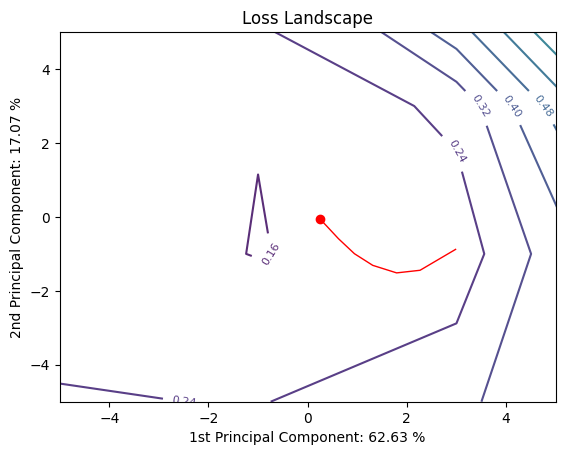

In [17]:
plot_loss_landscape(xv_sw_pca, yv_sw_pca, x_range, y_range, M_sw, reduced_dirs_sw_pca, loss_grid_sw_pca, "pca", extra_params_sw_pca, include_path=True)

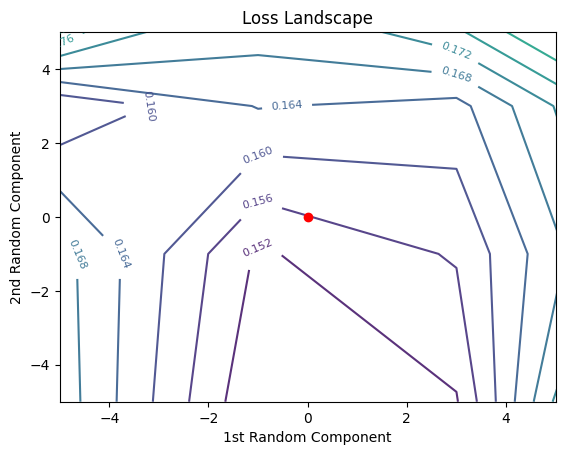

In [18]:
plot_loss_landscape(xv_sw_random, yv_sw_random, x_range, y_range, M_sw, reduced_dirs_sw_random, loss_grid_sw_random, "random", extra_params_sw_random, include_path=True)

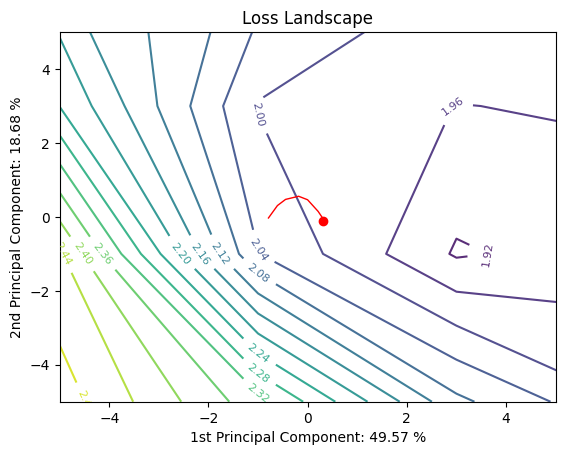

In [19]:
plot_loss_landscape(xv_hwa_pca, yv_hwa_pca, x_range, y_range, M_hwa, reduced_dirs_hwa_pca, loss_grid_hwa_pca, "pca", extra_params_hwa_pca, include_path=True)

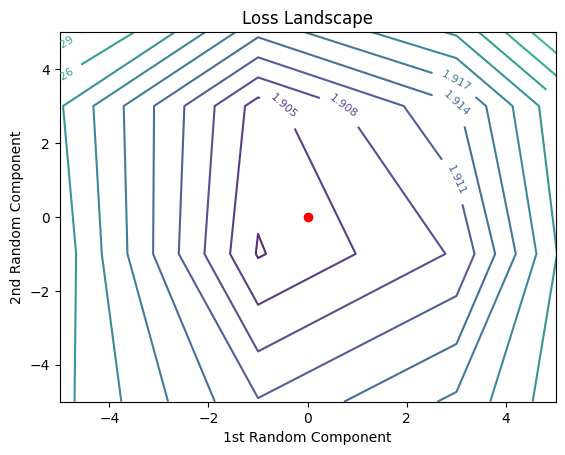

In [20]:
plot_loss_landscape(xv_hwa_random, yv_hwa_random, x_range, y_range, M_hwa, reduced_dirs_hwa_random, loss_grid_hwa_random, "random", extra_params_hwa_random, include_path=True)

## Conclusions

From the visualizations above, we can draw the following conclusions:
- The optimization trajectories lie in very low-dimensional spaces. The principal components capture them significantly well compared to the random direction vectors.
- Compared to the SW baseline, trajectories of the HWA network lie in higher dimensional spaces. This hints to the fact that device and system-level sources of noise inject noise in backpropagated gradients, making device networks more difficult to train.

These are in line with the conclusions reported in [2]. One can take this analysis a step further and compute the overall flatness/sharpness of these landscapes, and how they change as a function of device-level changes via XBTorch device models. XBTorch also allows easily creatign custom device models from experimental data. This is showcased in a later example.

## References

1. Li, H., Xu, Z., Taylor, G., Studer, C., & Goldstein, T. (2018). Visualizing the loss landscape of neural nets. Advances in neural information processing systems, 31.
2. Yousuf, O., Glasmann, A. L., Mazzoni, A. L., Najmaei, S., & Adam, G. C. (2025). Robust Hardware-Aware Neural Networks for FeFET-based Accelerators. IEEE Transactions on Nanotechnology.